# Lightweight Bounded Model Checker (BMC)
**CS 6315 – Automated Verification**

Le’Shawn Sears  
Final Project Report

## Introduction

1-2 paragraphs explanation

- What is bounded model checking
- Why symbolic encoding (Z3) is used
- What tool verifies (reachability + safety)
- Scope: small finitie-state transistion systems

## Project Architecture Overview

- Describe modules
    - `model.py`: Transistion system
    - `solver.py`: BMCSolver (Z3 wrapper)
    - `bmc.py`: run_bmc + encoding
    - `main.py`: CLI

Diagram (ASCII or NetworkX):
JSON Model → TransitionSystem → BMC Encoding → Z3 → SAT/UNSAT → Trace



Optional subsections:

### 1.1 Motivation
### 1.2 Background on Symbolic Encoding
### 1.3 Project Architecture Diagram



## 3. Bounded Model Checking Demonstration

Replaces sections 6–9.

Subsections:

### 3.1 Reachability Checking

- Run run_bmc(... safety=False)
- Show trace
- Explain SAT/UNSAT meaning

### 3.2 Safety Checking

- Run run_bmc(... safety=True)
- Show violation or safe result

### 3.3 Optional Trace Visualization (ASCII or graph)
### 3.4 Walkthrough of the Encoding

- State variables
- Initial state
- Transition relation
- Exclusivity
- Property encoding

This section demonstrates the tool and explains how it works.

## 4. Analysis: Performance, Edge Cases, and Behavior

Replaces sections 10–11 and analysis/discussion.

Subsections:

### 4.1 Runtime Benchmarking (k vs runtime)
### 4.2 Edge Case Verification

- Self-loop
- Dead-end
- Nondeterministic branching
- Multiple initial states

### 4.3 Observations on Scalability

- Why runtime increases
- Branching factor effects
- Z3’s behavior

This is the evaluation section.

## 5. Conclusion

Subsections:

### 5.1 Summary of what you built
### 5.2 What worked well / limitations
### 5.3 Future improvements

- LTL (Eventually, Always, Until)
- Loop detection for liveness
- Bit-vector encoding
- Model composition

## 2. Setup (Environment + Models)


Subsections:
- 2.1 Importing modules & initializing notebook
- 2.2 Loading Transition System models (toggle, traffic, unreachable)
- 2.3 Visualizing state graphs (NetworkX)
- 2.4 JSON model format explanation

### 2.1 Initialization

In [6]:
import sys, os
sys.path.append(".")      # so "bmc", "model", etc. can be imported

# Core BMC components
from bmc.model import TransitionSystem
from bmc.solver import BMCSolver
from bmc.bmc import run_bmc, extract_trace

# Visualization + utilities
import json
import matplotlib.pyplot as plt
import networkx as nx

### 2.2 Load transition System models

In [7]:
def load_model(path):
    return TransitionSystem.from_json(path)

toggle = load_model("examples/toggle.json")
traffic = load_model("examples/trafficlight.json")
unreachable = load_model("examples/unreachable.json")


In [8]:
toggle

TransitionSystem(name='ToggleSystem', states=['s0', 's1'], init='s0', transitions={'s0': ['s1'], 's1': ['s0']}, variables={})

In [9]:
unreachable

TransitionSystem(name='UnreachableExample', states=['s0', 's1', 'error'], init='s0', transitions={'s0': ['s1'], 's1': []}, variables={})

In [10]:
traffic

TransitionSystem(name='TrafficLightSystem', states=['Green', 'Yellow', 'Red', 'Error'], init='Green', transitions={'Green': ['Yellow'], 'Yellow': ['Red'], 'Red': ['Green', 'Error'], 'Error': []}, variables={})

### 2.3 Visualizing the Transistion System

In [11]:
def visualize_ts(ts):
    G = nx.DiGraph()
    for s, nxt in ts.transitions.items():
        for t in nxt:
            G.add_edge(s, t)
    plt.figure(figsize=(6,6))
    nx.draw_networkx(G, with_labels=True, node_color='lightblue')
    plt.axis('off')
    plt.show()


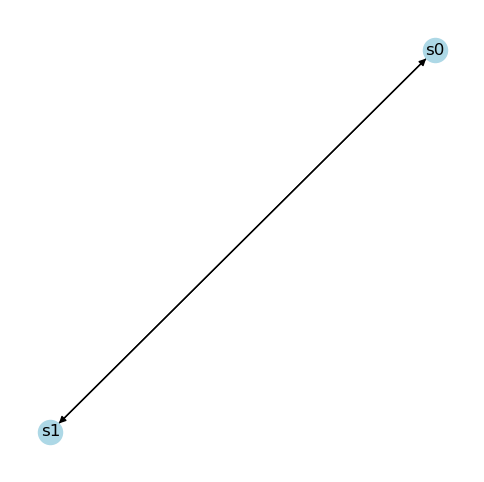

In [12]:
visualize_ts(toggle)

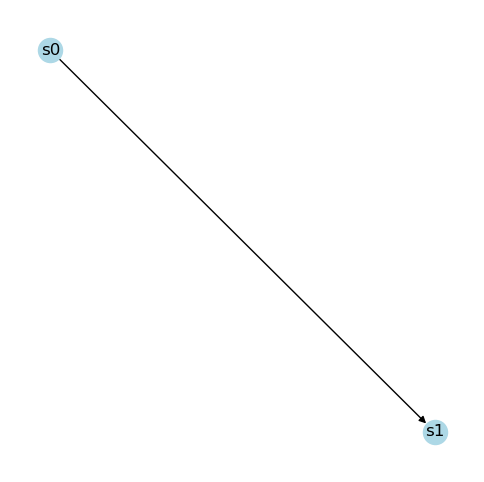

In [13]:
visualize_ts(unreachable)

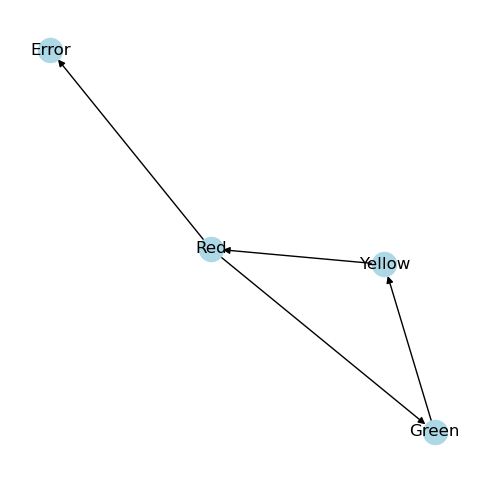

In [14]:
visualize_ts(traffic)

## 3. Running Bounded Model Checking: Reachability

- Reachability means ∃ path to state p within bound k
- SAT = reachable, UNSAT = not reachable

In [21]:
sat, trace = run_bmc(toggle, bound=5, target_state="s1", safety=False, verbose=False)
print("SAT:", sat)
print("Trace:", trace)

SAT: True
Trace: ['s0', 's1', 's0', 's1', 's0', 's1']


In [23]:
sat, trace = run_bmc(unreachable, bound=5, target_state="s1", safety=False, verbose=False)
print("SAT:", sat)
print("Trace:", trace)

SAT: True
Trace: ['s0', 's1', 's1', 's1', 's1']


In [24]:
sat, trace = run_bmc(traffic, bound=5, target_state="Error", safety=False, verbose=False)
print("SAT:", sat)
print("Trace:", trace)

SAT: True
Trace: ['Green', 'Yellow', 'Red', 'Error', 'Error']


## 4. BMC Review

1. Boolean state variables for each timestamp
2. Initial state constraint
3. Transisition relation
4. Exclusivity
5. Property encoding (reachability / safety)

## 5. Conclusion